Make a .tpr with dummy file, add the .gro file for coordinates, and then you can manipulate the "initial" collagen fibril configuration.

In [1]:
import MDAnalysis as md
import matplotlib.pyplot as plt
import numpy as np
import twistaly as tw

filedir = "ffa14/"

u = md.Universe(filedir + "colfib.tpr", filedir + "colfib_c.gro")
fib = u.select_atoms("protein")

In [83]:
chains = fib.fragments
com = fib.center_of_mass() / 10

See initial twist, and make transformation

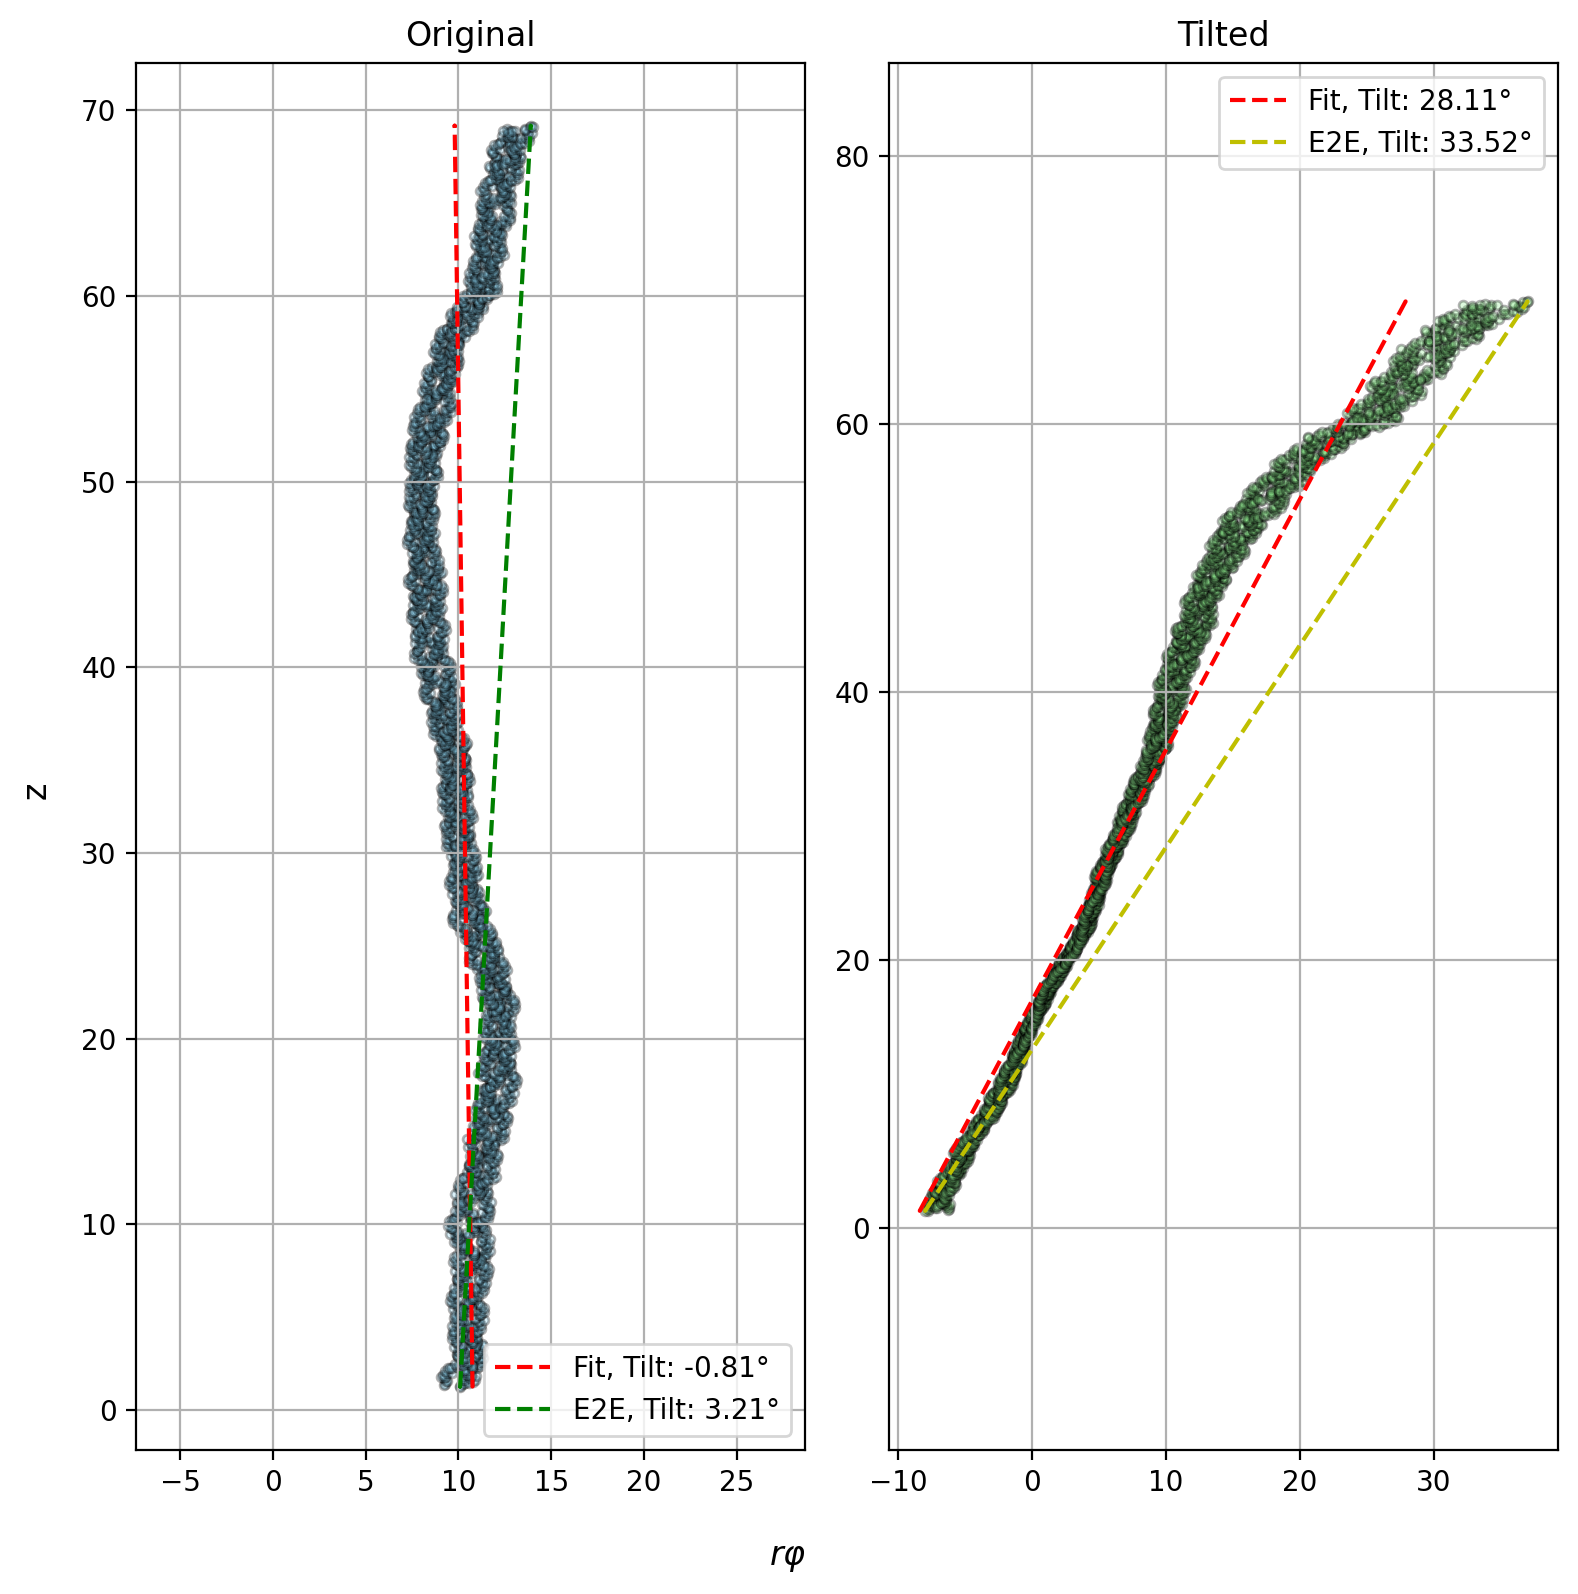

In [ ]:
group = "backbone"
mol = 0
molecule = chains[3*mol:3*mol + 3]
molecule_coords = (molecule[0].select_atoms(group) + molecule[1].select_atoms(group) + molecule[2].select_atoms(group)).positions / 10

r, phi, z = tw.cyl_proj(molecule_coords, x_c=com[0], y_c=com[1])
arc = r*phi

# --- Fit and Plot ---
fig, ax = plt.subplots(1, 2, dpi=200, figsize=(8,8))
ax[0].scatter(arc, z, alpha=0.3, edgecolor='k', facecolor='skyblue', s=10)
# Fit
m, b, _ = tw.ortreglinfit(z, arc)
ax[0].plot(m*z + b, z, linestyle='dashed', color='r',
           label=f"Fit, Tilt: {np.rad2deg(np.atan(m)):.2f}°")
# e2e
imin = np.argmin(z)
imax = np.argmax(z)
minp = [z[imin], arc[imin]]
maxp = [z[imax], arc[imax]]
m = (maxp[1] - minp[1]) / (maxp[0] - minp[0])
b = maxp[1] - m*maxp[0]
ax[0].plot(m*z + b, z, linestyle='dashed', color='g',
           label=f"E2E, Tilt: {np.rad2deg(np.atan(m)):.2f}°")

ax[0].set_title("Original")
ax[0].legend()
ax[0].grid(True)
ax[0].axis("equal")

# --- Tilt Molecule ---
z_middle = (max(z) + min(z))/2
psi = 10 #deg
mpsi = 0.02
psi_0 = 5 #deg
#twist = lambda z: (1/r)*np.tan(np.deg2rad(psi))*(z - z_middle - min(z))
twist = lambda z: mpsi*(z - z_middle - min(z))
#twist = lambda z: (1/r)*np.tan(np.deg2rad(psi_0)*r)*(z - z_middle - min(z))
phi_nw = phi + twist(z)
arc_nw = r*phi_nw

ax[1].scatter(arc_nw, z, alpha=0.3, edgecolor='k', facecolor='lightgreen', s=10)
# Fit
m, b, _ = tw.ortreglinfit(z, arc_nw)
ax[1].plot(m*z + b, z, linestyle='dashed', color='r',
           label=f"Fit, Tilt: {np.rad2deg(np.atan(m)):.2f}°")
# E2E
imin = np.argmin(z)
imax = np.argmax(z)
minp = [z[imin], arc_nw[imin]]
maxp = [z[imax], arc_nw[imax]]
m = (maxp[1] - minp[1]) / (maxp[0] - minp[0])
b = maxp[1] - m*maxp[0]
ax[1].plot(m*z + b, z, linestyle='dashed', color='y',
           label=f"E2E, Tilt: {np.rad2deg(np.atan(m)):.2f}°")

ax[1].set_title(r"Tilted")
ax[1].legend()
ax[1].grid(True)
ax[1].axis("equal")

fig.supxlabel(r'$r\varphi$')
fig.supylabel('z')
plt.tight_layout()
plt.show()